# EDA for the basic L-UCB model (STAR data)

The basic model (`L_UCB_SLT_simulation.ipynb`) needs five things. Each section below checks one of them in the STAR data.

| Model input | What the model assumes | EDA section |
|---|---|---|
| Horizon **T** | how many split livers arrive | 1. Split livers per year |
| Reward | 1-year graft survival (success / failure) | 2. One-year graft survival |
| Arms and **α** (full potential) | UPMC, AGH, VAPHS with PSR survival 0.890 / 0.934 / 0.884 | 3. The Pittsburgh arms |
| Learning curve **ω** | survival rises with a center's split experience | 4. Is there a learning curve? |
| Covariate prior | LDLT volume and a pediatric program signal readiness | 5. Do the covariates predict split results? |

Only aggregated numbers are printed. (Data Use Agreement).

## 0. Settings and data

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm
import warnings
from statsmodels.discrete.conditional_models import ConditionalLogit
import re

LIVER_DIR  = Path("/Users/utami/CodeFolder/DatatoAction/FinalProject/Rawdata/Delimited_TextFile_202606/Liver")
CENTER_DTA = Path("/Users/utami/CodeFolder/DatatoAction/FinalProject/Rawdata/CTR_IDS/liver_ctr_ids.DTA")
DD_DIR = Path("/Users/utami/CodeFolder/DatatoAction/FinalProject/Rawdata/Delimited_TextFile_202606/Deceased_Donor")
WLH_DAT = Path("/Users/utami/CodeFolder/DatatoAction/FinalProject/Rawdata/Delimited_TextFile_202606/Liver/Waiting List History/LIVER_WLHISTORY_DATA.DAT")
WLH_HTM = WLH_DAT.with_suffix(".htm")
OUT = Path("/Users/utami/CodeFolder/DatatoAction/FinalProject")   # folder to save into
MIN_CELL   = 11       #User Data Agreement
START_YEAR = 1987


def safe(n):
    """Show counts from 1 to MIN_CELL-1 as '<11'."""
    return f"<{MIN_CELL}" if 0 < n < MIN_CELL else str(int(n))

def pct(surv):
    """Survival % from a column of 1/0, hidden if survivors or failures are fewer than MIN_CELL."""
    ok, n = int(surv.sum()), len(surv)
    return "suppressed" if min(ok, n - ok) < MIN_CELL else f"{100 * ok / n:.1f}%"

# waiting-list analysis settings
WL_FROM      = 2002                          # MELD-based allocation began in 2002
URGENT_CODES = ["6011", "6010"]              # 6011 = Status 1A, 6010 = old Status 1 (STAR data dictionary)
BUCKETS      = ["6-19", "20-29", "30-34", "35-39", "40+"]


In [2]:
# Column names come from LIVER_DATA.htm (the .DAT file has no header row)
names = None
for table in pd.read_html(LIVER_DIR / "LIVER_DATA.htm"):
    for col in table.columns:
        values = table[col].astype(str).str.strip().tolist()
        if "TRR_ID_CODE" in values:
            names = [v for v in values if v and v != "nan"]

use = ["TRR_ID_CODE", "TX_DATE", "TX_PROCEDUR_TY", "DON_TY", "AGE_GROUP",
       "GTIME", "GSTATUS", "PTIME", "PSTATUS"]
liver = pd.read_csv(LIVER_DIR / "LIVER_DATA.DAT", sep="\t", header=None, names=names, usecols=use,
                    dtype=str, encoding="latin-1", low_memory=False)
liver = liver[liver["TRR_ID_CODE"].notna()].copy()                     # transplants only

liver["TX_DATE"] = pd.to_datetime(liver["TX_DATE"], errors="coerce")
for c in ["TX_PROCEDUR_TY", "GTIME", "GSTATUS", "PTIME", "PSTATUS"]:
    liver[c] = pd.to_numeric(liver[c], errors="coerce")
liver["YEAR"] = liver["TX_DATE"].dt.year

# Transplant center for every transplant
centers = pd.read_stata(CENTER_DTA, columns=["TRR_ID_CODE", "TX_CTR"]).astype(str)  #Reads only two columns from the center file: the transplant ID and its center.
liver = liver.merge(centers, on="TRR_ID_CODE", how="left")               #Joins them by transplant ID, so every transplant row in liver gets a new column, TX_CTR. how="left" keeps every transplant even if no center is found (it would then show nan).
liver["CODE"] = liver["TX_CTR"].str[:4]                                 # transplant center code, Keeps the first 4 characters as a short code.

# Graft types
liver["SPLIT"] = (liver["DON_TY"] == "C") & liver["TX_PROCEDUR_TY"].isin([703, 706])    #C means Deceased donor, 703 = Split Liver, 706= Split Liver with Pancreas (technical reasons)
liver["WHOLE"] = (liver["DON_TY"] == "C") & liver["TX_PROCEDUR_TY"].isin([701, 704])    #701=Whole Liver, 704 = Whole Liver with Pancreas (technical reasons)
liver["LDLT"]  = liver["DON_TY"] == "L"             #L means Living donor, LDLT means Living-donor transplant: used as a skill signal in the baseline model
liver["ADULT"] = liver["AGE_GROUP"] == "A"          # A means Adult recipient ("P" = pediatric)

# Reward: 1 = graft and patient alive at 1 year, 0 = graft failed or patient died within 365 days.
# Keep only transplants with a full year of follow-up.
data_end = liver["TX_DATE"].max()       #the bandit's reward
failed = ((liver["GSTATUS"] == 1) & (liver["GTIME"] <= 365)) | ((liver["PSTATUS"] == 1) & (liver["PTIME"] <= 365))  #status 1 means graft/patient failed,GTIME/PTIME is the time to failure in days. So this line checks if either the graft or patient failed within 365 days.
liver["SURV1"] = (~failed).astype(int)              #SURV1 = 1 if the graft and patient were alive at one year, 0 if not. This is the success/failure each bandit arm produces.
liver["KNOWN"] = (liver["TX_DATE"] <= data_end - pd.Timedelta(days=365)) & (failed | (liver["GTIME"] > 365))    #KNOWN=True only if we really know the one-year result:And either it failed within the year, or it was followed for more than 365 days. Survival percentages are computed only on KNOWN transplants.

print(f"Transplants: {safe(len(liver))} | {liver['TX_DATE'].min().date()} to {data_end.date()}")
print(f"Split grafts: {safe(liver['SPLIT'].sum())} | whole deceased-donor: {safe(liver['WHOLE'].sum())} | "
      f"living-donor: {safe(liver['LDLT'].sum())}")

summary = pd.DataFrame({
    "metric": ["Transplants", "First transplant date", "Last transplant date",
               "Split grafts", "Whole deceased-donor", "Living-donor"],
    "value":  [len(liver), liver["TX_DATE"].min().date(), data_end.date(),
               int(liver["SPLIT"].sum()), int(liver["WHOLE"].sum()), int(liver["LDLT"].sum())]})
summary.to_csv(OUT / "liver_summary.csv", index=False)
print("saved", OUT / "liver_summary.csv")

#the cleaned transplant-level table, one row per transplant 
liver.to_csv(OUT / "liver_transplants_clean.csv", index=False)

/var/folders/j1/5wbw5ngd1h91cj22w2k_vh3c0000gn/T/ipykernel_10972/1603673867.py:21: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
  centers = pd.read_stata(CENTER_DTA, columns=["TRR_ID_CODE", "TX_CTR"]).astype(str)  #Reads only two columns from the center file: the transplant ID and its center.


Transplants: 242156 | 1987-09-30 to 2026-06-30
Split grafts: 5044 | whole deceased-donor: 223760 | living-donor: 11326
saved /Users/utami/CodeFolder/DatatoAction/FinalProject/liver_summary.csv


# PROBLEM: WAITING LIST FOR LIVER FOR ADULT*

In [3]:
def read_names(htm, key):
    """Column names from a STAR .htm file (the .DAT has no header row)."""
    for table in pd.read_html(htm):
        for col in table.columns:
            values = table[col].astype(str).str.strip().tolist()
            if key in values:
                return [v for v in values if v and v != "nan"]
    raise AssertionError(f"Could not read column names from {htm}")

wlh_names = read_names(WLH_HTM, "WL_ID_CODE")
cols = ["WL_ID_CODE", "CHG_TY", "UNOS_CAND_STAT_CD", "CHG_DATE", "MELD_OR_PELD", "MELD_PELD_LAB_SCORE"]

rec_counts, pairs, firsts, removals = pd.Series(dtype="float64"), [], [], []
for ch in pd.read_csv(WLH_DAT, sep="\t", header=None, names=wlh_names, usecols=cols, dtype=str,
                      encoding="latin-1", chunksize=1_000_000):
    ch["UNOS_CAND_STAT_CD"] = ch["UNOS_CAND_STAT_CD"].fillna("(missing)")
    rec_counts = rec_counts.add(ch["UNOS_CAND_STAT_CD"].value_counts(), fill_value=0)       # records per status code
    pairs.append(ch[["UNOS_CAND_STAT_CD", "WL_ID_CODE"]].drop_duplicates())                  # for distinct registrations per code
    ch["CHG_DATE"] = pd.to_datetime(ch["CHG_DATE"], format="%m/%d/%Y", errors="coerce")
    ch["_o"] = (ch["CHG_TY"] != "A").astype(int)                                              # on ties, the 'A' (addition) record first
    firsts.append(ch.sort_values(["CHG_DATE", "_o"]).drop_duplicates("WL_ID_CODE"))
    removals.append(ch.loc[ch["CHG_TY"] == "D", ["WL_ID_CODE", "CHG_DATE"]])                 # CHG_TY D = removal

pairs = pd.concat(pairs).drop_duplicates()
first = (pd.concat(firsts).sort_values(["CHG_DATE", "_o"]).drop_duplicates("WL_ID_CODE")
           .set_index("WL_ID_CODE"))                                   # first record = listing, one row per registration
removed = pd.concat(removals).groupby("WL_ID_CODE")["CHG_DATE"].min()  # first removal date per registration

first["YEAR"]     = first["CHG_DATE"].dt.year
first["LAB_MELD"] = pd.to_numeric(first["MELD_PELD_LAB_SCORE"], errors="coerce")
first["TYPE"]     = first["MELD_OR_PELD"].where(first["MELD_OR_PELD"].isin(["MELD", "PELD"]), "other/none")
# No age in this file: adult = MELD-scored at first record, or urgent status (1A / old Status 1) that is not PELD-scored
first["ADULT"]    = (first["TYPE"] == "MELD") | (first["UNOS_CAND_STAT_CD"].isin(URGENT_CODES) & (first["TYPE"] != "PELD"))
last_full = first["CHG_DATE"].max().year - 1                           # drop the unfinished last year

print(f"Records: {int(rec_counts.sum()):,} | registrations: {len(first):,} | with a removal record: {len(removed):,}")
print(f"First records dated {first['CHG_DATE'].min():%Y-%m-%d} to {first['CHG_DATE'].max():%Y-%m-%d} | last full year: {last_full}")

Records: 4,785,637 | registrations: 372,446 | with a removal record: 363,708
First records dated 1995-04-01 to 2026-06-30 | last full year: 2025


In [4]:
status_tab = pd.DataFrame({"all_records": rec_counts.astype(int),
                           "registrations_ever_with_code": pairs.groupby("UNOS_CAND_STAT_CD").size(),
                           "registrations_first_record": first.groupby("UNOS_CAND_STAT_CD").size()}).fillna(0).astype(int)

# Labels from the STAR data dictionary, "STAT" format. MELD/PELD codes are 6200 + score.
LABELS = {"6002": "LI: Old status 2", "6004": "LI: Old status 4", "6010": "LI: Status 1 (old)", "6011": "LI: Status 1A",
          "6012": "LI: Status 1B", "6020": "LI: Status 2A", "6030": "LI: Status 2B", "6040": "LI: Status 3",
          "6050": "LI: MELD/PELD (generic)", "6999": "LI: Temporarily inactive", "(missing)": "Not reported"}
def status_label(code):
    if code in LABELS:
        return LABELS[code]
    if code.isdigit() and 6189 <= int(code) <= 6299:
        return f"LI: MELD/PELD {int(code) - 6200}"
    return "not a liver code or not in this list"
status_tab.insert(0, "meaning", [status_label(c) for c in status_tab.index])
status_tab = status_tab.sort_values("all_records", ascending=False)
status_nonmeld = status_tab[~status_tab.index.map(lambda c: c.isdigit() and 6189 <= int(c) <= 6299)]

pd.set_option("display.max_rows", None, "display.width", 200)
print(f"{len(status_tab)} distinct status codes | {int(status_tab['all_records'].sum()):,} records | {len(first):,} registrations")
print(status_tab.to_string())
print("\nNon-MELD statuses only (everything that is not 6189-6299):")
print(status_nonmeld.to_string())

status_tab.to_csv(OUT / "status_codes_counts.csv")
status_nonmeld.to_csv(OUT / "status_codes_non_MELD.csv")
print("saved to", OUT)

107 distinct status codes | 4,785,637 records | 372,446 registrations
                                                meaning  all_records  registrations_ever_with_code  registrations_first_record
UNOS_CAND_STAT_CD                                                                                                             
6999                           LI: Temporarily inactive       453086                        123106                        7674
6206                                    LI: MELD/PELD 6       357429                        104781                        7855
6222                                   LI: MELD/PELD 22       241072                         72462                        8625
6040                                       LI: Status 3       189336                         48551                       41773
6210                                   LI: MELD/PELD 10       157012                         40388                       13948
6225                                   LI

Status 1 / 1A first records 2002-2025: 11,315; by MELD/PELD label:
TYPE
MELD          8777
PELD          2422
other/none     116

New registrations per year by MELD bucket (2002-2025); 40+ = MELD 40 plus Status 1 / 1A
BUCKET  6-19  20-29  30-34  35-39   40+  total
YEAR                                          
2002    5125   1048    214    152   660   7199
2003    6651   1416    290    187   659   9203
2004    6864   1670    335    219   723   9811
2005    6952   1777    390    264   863  10246
2006    7047   1903    417    262   715  10344
2007    7039   1919    395    303   738  10394
2008    7096   1937    432    302   713  10480
2009    7160   1994    441    324   683  10602
2010    7621   2170    498    386   688  11363
2011    7493   2275    534    373   675  11350
2012    7366   2181    487    383   649  11066
2013    7565   2271    523    416   650  11425
2014    7334   2297    602    437   736  11406
2015    7248   2315    633    487   737  11420
2016    6795   3139    892    

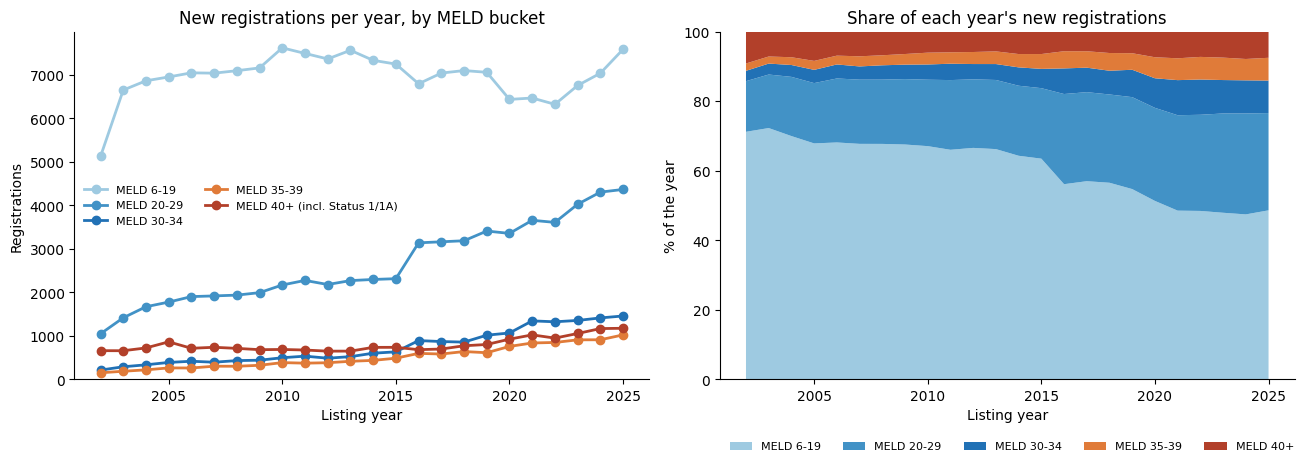

In [5]:
yr = first["YEAR"].between(WL_FROM, last_full)
is_urgent = first["UNOS_CAND_STAT_CD"].isin(URGENT_CODES)
print(f"Status 1 / 1A first records {WL_FROM}-{last_full}: {int((yr & is_urgent).sum()):,}; by MELD/PELD label:")
print(first[yr & is_urgent]["TYPE"].value_counts().to_string())

keep = yr & (((first["TYPE"] == "MELD") & first["LAB_MELD"].notna()) | (is_urgent & (first["TYPE"] != "PELD")))
bk = first[keep].copy()
bk["BUCKET"] = pd.cut(bk["LAB_MELD"].round(), bins=[-np.inf, 19, 29, 34, 39, np.inf], labels=BUCKETS).astype(object)
bk.loc[bk["UNOS_CAND_STAT_CD"].isin(URGENT_CODES), "BUCKET"] = "40+"          # Status 1 / 1A go into 40+
bk["BUCKET"] = pd.Categorical(bk["BUCKET"], categories=BUCKETS)

bucket_cnt = (bk.groupby(["YEAR", "BUCKET"], observed=False).size().unstack(fill_value=0)
                .reindex(index=range(WL_FROM, last_full + 1), columns=BUCKETS, fill_value=0))
bucket_shr = 100 * bucket_cnt.div(bucket_cnt.sum(axis=1), axis=0)
print(f"\nNew registrations per year by MELD bucket ({WL_FROM}-{last_full}); 40+ = MELD 40 plus Status 1 / 1A")
print(bucket_cnt.assign(total=bucket_cnt.sum(axis=1)).to_string())
print("\nShare of each year (%)"); print(bucket_shr.round(1).to_string())
bucket_cnt.to_csv(OUT / "new_registrations_by_meld_bucket.csv")
bucket_shr.round(1).to_csv(OUT / "new_registrations_by_meld_bucket_share_pct.csv")

bcolors = ["#9ecae1", "#4292c6", "#2171b5", "#e07b39", "#b2402a"]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
for b, col in zip(BUCKETS, bcolors):
    axes[0].plot(bucket_cnt.index, bucket_cnt[b], marker="o", lw=2, color=col,
                 label=f"MELD {b}" + (" (incl. Status 1/1A)" if b == "40+" else ""))
axes[0].set_title("New registrations per year, by MELD bucket"); axes[0].set_ylabel("Registrations"); axes[0].set_ylim(bottom=0)
axes[1].stackplot(bucket_shr.index, [bucket_shr[b] for b in BUCKETS], colors=bcolors, labels=[f"MELD {b}" for b in BUCKETS])
axes[1].set_title("Share of each year's new registrations"); axes[1].set_ylabel("% of the year"); axes[1].set_ylim(0, 100)
for ax in axes:
    ax.set_xlabel("Listing year"); ax.spines[["top", "right"]].set_visible(False)
axes[0].legend(fontsize=8, frameon=False, ncol=2)
axes[1].legend(fontsize=8, frameon=False, loc="upper left", ncol=5, bbox_to_anchor=(0, -0.15))
plt.tight_layout(); plt.show()

Adult liver waitlist, 2002-2025  (293,657 registrations, 285,204 with a removal record)
      new registrations  removals  net change
2002               7217      3197        4020
2003               9228      6000        3228
2004               9838      7575        2263
2005              10258      8608        1650
2006              10366      9305        1061
2007              10420      9623         797
2008              10490      9883         607
2009              10604     10038         566
2010              11367     10542         825
2011              11356     10922         434
2012              11068     11125         -57
2013              11427     11422           5
2014              11406     11810        -404
2015              11423     12052        -629
2016              12107     12486        -379
2017              12355     12811        -456
2018              12558     13064        -506
2019              12914     13444        -530
2020              12550     13400     

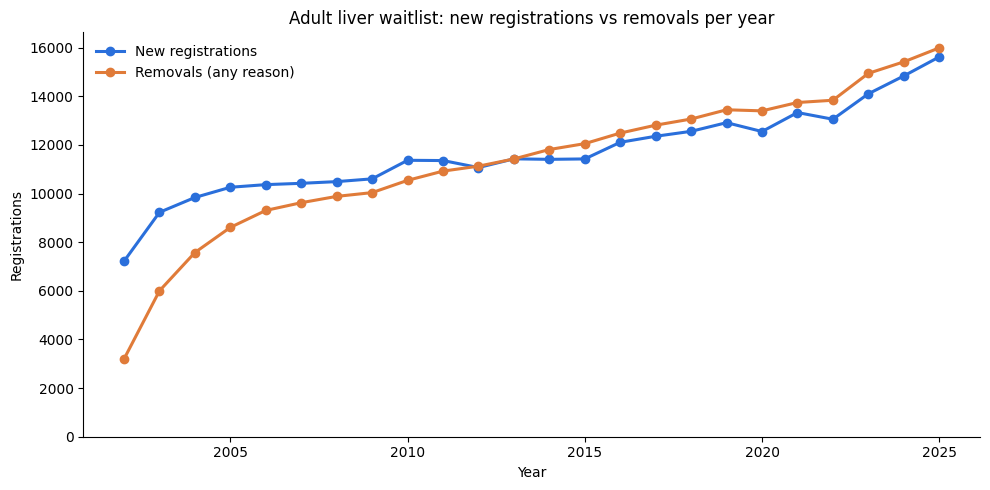

In [6]:
ADULT_ONLY = True                                     # False = includes children
use = first[first["ADULT"]] if ADULT_ONLY else first
years = range(WL_FROM, last_full + 1)
added   = use["YEAR"].value_counts().reindex(years, fill_value=0).sort_index()
removed_by_year = removed.reindex(use.index).dropna().dt.year.value_counts().reindex(years, fill_value=0).sort_index()

flow_tbl = pd.DataFrame({"new registrations": added, "removals": removed_by_year})
flow_tbl["net change"] = flow_tbl["new registrations"] - flow_tbl["removals"]
print(f"{'Adult' if ADULT_ONLY else 'All'} liver waitlist, {WL_FROM}-{last_full}  "
      f"({len(use):,} registrations, {int(use.index.isin(removed.index).sum()):,} with a removal record)")
print(flow_tbl.to_string())
flow_tbl.to_csv(OUT / "registrations_vs_removals.csv")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(flow_tbl.index, flow_tbl["new registrations"], marker="o", lw=2.2, color="#2a6fdb", label="New registrations")
ax.plot(flow_tbl.index, flow_tbl["removals"],          marker="o", lw=2.2, color="#e07b39", label="Removals (any reason)")
ax.set_title(f"{'Adult' if ADULT_ONLY else 'All'} liver waitlist: new registrations vs removals per year")
ax.set_xlabel("Year"); ax.set_ylabel("Registrations"); ax.set_ylim(bottom=0)
ax.spines[["top", "right"]].set_visible(False); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

LIVER_DATA rows: 400,961 | distinct WL_ID_CODE: 399,270 | with a REM_CD: 400,961

Adult removals per year by reason (2002-2025)
GROUP  Transplanted  Died on the list  Too sick / medically unsuitable  Condition improved  Transferred to another center  Other / unknown  total
YEAR                                                                                                                                             
2002           2194               539                              170                 187                             23               84   3197
2003           4282               972                              282                 156                             79              229   6000
2004           5288              1262                              383                 176                            117              349   7575
2005           5869              1434                              472                 244                            135              454   8

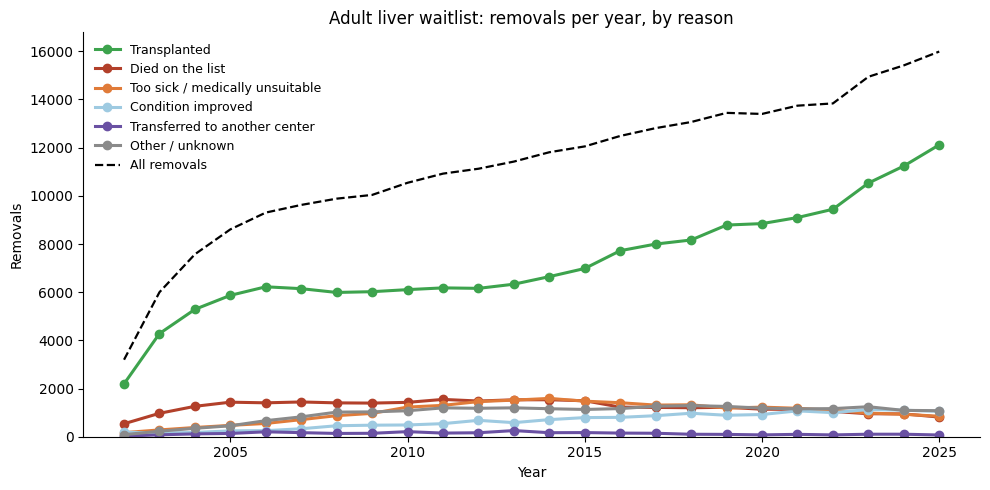

In [7]:
# Removal reason (REM_CD) is in LIVER_DATA; match it to the removal date above on WL_ID_CODE.
liver_names = read_names(LIVER_DIR / "LIVER_DATA.htm", "TRR_ID_CODE")
rc = pd.read_csv(LIVER_DIR / "LIVER_DATA.DAT", sep="\t", header=None, names=liver_names, usecols=["WL_ID_CODE", "REM_CD"],
                 dtype=str, encoding="latin-1", low_memory=False)
print(f"LIVER_DATA rows: {len(rc):,} | distinct WL_ID_CODE: {rc['WL_ID_CODE'].nunique():,} | with a REM_CD: {rc['REM_CD'].notna().sum():,}")
rc = rc.dropna(subset=["WL_ID_CODE"]).drop_duplicates("WL_ID_CODE").set_index("WL_ID_CODE")["REM_CD"]

# STAR data dictionary, format REMCD
REASON_GROUPS = {"Transplanted": ["2", "3", "4", "14", "15", "18", "19", "21", "22", "23"],
                 "Died on the list": ["8"],
                 "Too sick / medically unsuitable": ["13", "5"],
                 "Condition improved": ["12"],
                 "Transferred to another center": ["7"]}
code_to_group = {c: g for g, cs in REASON_GROUPS.items() for c in cs}
ORDER = list(REASON_GROUPS) + ["Other / unknown"]

rem = pd.DataFrame({"removed": removed}).join(first[["ADULT"]]).dropna()
rem = rem[rem["ADULT"].astype(bool) & rem["removed"].dt.year.between(WL_FROM, last_full)].copy()
rem["REM_CD"] = rc.reindex(rem.index).values
rem["GROUP"]  = rem["REM_CD"].map(code_to_group).fillna("Other / unknown")
rem["YEAR"]   = rem["removed"].dt.year

rem_cnt = (rem.groupby(["YEAR", "GROUP"]).size().unstack(fill_value=0)
              .reindex(columns=ORDER, fill_value=0).reindex(range(WL_FROM, last_full + 1), fill_value=0))
rem_shr = 100 * rem_cnt.div(rem_cnt.sum(axis=1), axis=0)
print(f"\nAdult removals per year by reason ({WL_FROM}-{last_full})")
print(rem_cnt.assign(total=rem_cnt.sum(axis=1)).to_string())
print("\nShare of each year's removals (%)"); print(rem_shr.round(1).to_string())
print("\nREM_CD values inside 'Other / unknown':")
print(rem.loc[rem["GROUP"] == "Other / unknown", "REM_CD"].value_counts(dropna=False).head(8).to_string())
rem_cnt.assign(total=rem_cnt.sum(axis=1)).to_csv(OUT / "removals_by_reason.csv")
rem_shr.round(1).to_csv(OUT / "removals_by_reason_share_pct.csv")

rcolors = ["#3da34d", "#b2402a", "#e07b39", "#9ecae1", "#6a51a3", "#8a8a8a"]
fig, ax = plt.subplots(figsize=(10, 5))
for g, c in zip(ORDER, rcolors):
    ax.plot(rem_cnt.index, rem_cnt[g], marker="o", lw=2.2, color=c, label=g)
ax.plot(rem_cnt.index, rem_cnt[ORDER].sum(axis=1), lw=1.6, ls="--", color="black", label="All removals")
ax.set_title("Adult liver waitlist: removals per year, by reason")
ax.set_xlabel("Year"); ax.set_ylabel("Removals"); ax.set_ylim(bottom=0)
ax.spines[["top", "right"]].set_visible(False); ax.legend(frameon=False, fontsize=9)
plt.tight_layout(); plt.show()

## 1. Split livers per year → horizon T
The model runs T = 1000 liver arrivals. This shows how many split grafts really happen, nationally and in Pittsburgh,
so T can be read as "how many years of real activity".

Split grafts per year (national), since 1987
  1988: 16
  1989: 26
  1990: 18
  1991: 12
  1992: <11
  1993: 14
  1994: 32
  1995: 20
  1996: 80
  1997: 114
  1998: 140
  1999: 150
  2000: 168
  2001: 153
  2002: 153
  2003: 178
  2004: 149
  2005: 167
  2006: 120
  2007: 166
  2008: 155
  2009: 176
  2010: 170
  2011: 143
  2012: 152
  2013: 168
  2014: 135
  2015: 140
  2016: 187
  2017: 195
  2018: 201
  2019: 208
  2020: 150
  2021: 150
  2022: 169
  2023: 197
  2024: 203
  2025: 181

Adult split grafts per year: national 60
T = 1,000 arrivals equals about 17 years of national adult split activity


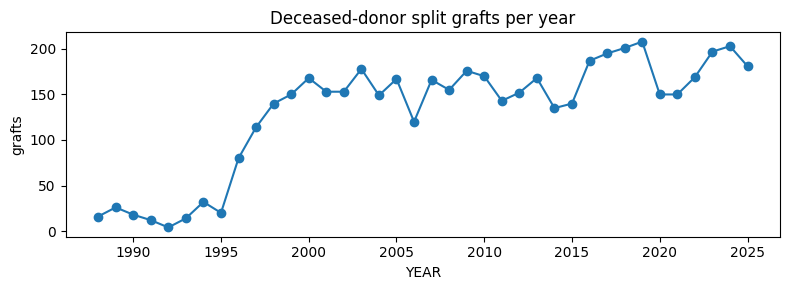

In [8]:
split = liver[liver["SPLIT"] & (liver["YEAR"] < data_end.year)]          # drop the unfinished last year
per_year = split.groupby("YEAR").size()
print("Split grafts per year (national), since", START_YEAR)
for y, n in per_year[per_year.index >= START_YEAR].items():
    print(f"  {y}: {safe(n)}")

recent = split[split["YEAR"] >= START_YEAR]
years = recent["YEAR"].nunique()
adult_per_year = recent["ADULT"].sum() / years
pgh_adult_per_year = (recent["ADULT"] & recent["CODE"].isin(["PAPT", "PAAG", "PAVA"])).sum() / years
print(f"\nAdult split grafts per year: national {adult_per_year:.0f}")
print(f"T = 1,000 arrivals equals about {1000 / adult_per_year:.0f} years of national adult split activity")

per_year[per_year.index >= START_YEAR].plot(marker="o", figsize=(8, 3), title="Deceased-donor split grafts per year")
plt.ylabel("grafts"); plt.tight_layout(); plt.show()

In [9]:
# Each split liver = one DONOR_ID with split-coded grafts (703/706). What age mix did its recipients have?
extra = pd.read_csv(LIVER_DIR / "LIVER_DATA.DAT", sep="\t", header=None, names=names,
                    usecols=["TRR_ID_CODE", "DONOR_ID"], dtype=str, encoding="latin-1", low_memory=False)
sp = liver[liver["SPLIT"] & (liver["TX_DATE"] >= f"{START_YEAR}-01-01")].merge(extra, on="TRR_ID_CODE", how="left")
sp = sp[sp["DONOR_ID"].notna()]                      # remove records without a donor ID

per_liver = sp.groupby("DONOR_ID").agg(halves=("TRR_ID_CODE", "size"),
                                       adults=("ADULT", "sum"),
                                       year=("YEAR", "min"),
                                       centers=("TX_CTR", "nunique"))
both = per_liver[per_liver["halves"] == 2].copy()    # keep only donors where both halves were transplanted
both["MIX"] = both["adults"].map({2: "adult + adult", 1: "adult + child", 0: "child + child"})

print(f"Split livers with both halves transplanted, by recipient mix ({START_YEAR}+)")
for mix in ["child + child", "adult + child", "adult + adult"]:
    g = both[both["MIX"] == mix]
    print(f"  {mix:14s} livers {safe(len(g)):>6s} | same center {safe((g['centers'] == 1).sum()):>6s}")

aa = sp[sp["DONOR_ID"].isin(both.index[both["MIX"] == "adult + adult"])]
print(f"\nAdult-to-adult split grafts: {safe(len(aa))}, at {safe(aa['TX_CTR'].nunique())} programs")
k = aa[aa["KNOWN"]]
if len(k) >= MIN_CELL and min(k["SURV1"].sum(), len(k) - k["SURV1"].sum()) >= MIN_CELL:
    print(f"One-year graft survival: {100 * k['SURV1'].mean():.1f}% (n {len(k)})")
else:
    print("One-year survival: suppressed (fewer than 11 failures or survivors)")

Split livers with both halves transplanted, by recipient mix (1987+)
  child + child  livers    195 | same center    140
  adult + child  livers   2047 | same center    714
  adult + adult  livers    121 | same center    113

Adult-to-adult split grafts: 242, at 35 programs
One-year graft survival: 73.3% (n 232)


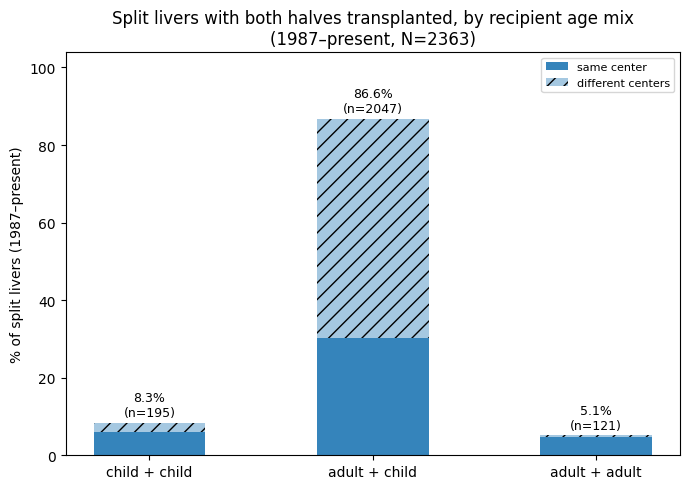

In [10]:
# Visualize the number of split livers since START_YEAR, split into same-center vs different-center
mix_order = ["child + child", "adult + child", "adult + adult"]

totals = both.groupby("MIX").size().reindex(mix_order, fill_value=0)
same_center = both[both["centers"] == 1].groupby("MIX").size().reindex(mix_order, fill_value=0)
diff_center = totals - same_center
grand_total = totals.sum()

# Convert to percentage of all split livers (START_YEAR-present)
same_pct = 100 * same_center / grand_total
diff_pct = 100 * diff_center / grand_total

fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(len(mix_order))
width = 0.5

# Same-center portion (bottom, solid)
ax.bar(x, same_pct.values, width, label="same center", color="C0", alpha=0.9)
# Different-center portion (stacked on top, hatched)
ax.bar(x, diff_pct.values, width, bottom=same_pct.values,
       label="different centers", color="C0", alpha=0.4, hatch="//")

# Annotate each bar with its total % and raw n
for j, mix in enumerate(mix_order):
    total_pct = same_pct[mix] + diff_pct[mix]
    n = totals[mix]
    if total_pct > 0:
        ax.text(x[j], total_pct + 1, f"{total_pct:.1f}%\n(n={int(n)})",
                 ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(mix_order)
ax.set_ylabel(f"% of split livers ({START_YEAR}–present)")
ax.set_ylim(0, max((same_pct + diff_pct).max() * 1.2, 5))
ax.set_title(f"Split livers with both halves transplanted, by recipient age mix\n({START_YEAR}–present, N={int(grand_total)})")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

## SPLIT LIVERS-HOW MANY SEGMENTS (HALF OF LIVER) WERE NOT TRANSPLANTED


In [11]:
# SPLIT LIVERS: HOW MANY SEGMENTS WERE NOT TRANSPLANTED? ;Uses STAR's deceased donor file. A liver that was split has two segments, LIS1 and LIS2, each with a disposition.
# Disposition codes (STAR format DONDISP): 3 Organ not recovered, 4 Recovered not for transplant, 5 Recovered for transplant but not transplanted, 6 Transplanted.

FROM_YEAR = START_YEAR

# Column names come from the .htm file (the .DAT file has no header row)
dd_names = None
for table in pd.read_html(DD_DIR / "DECEASED_DONOR_DATA.htm"):
    for col in table.columns:
        values = table[col].astype(str).str.strip().tolist()
        if "DONOR_ID" in values:
            dd_names = [v for v in values if v and v != "nan"]

cols = ["DONOR_ID", "DON_DATE", "LIS1_DISPOSITION", "LIS2_DISPOSITION", "LIS1_DISCARD_CD", "LIS2_DISCARD_CD"]
dd = pd.read_csv(DD_DIR / "DECEASED_DONOR_DATA.DAT", sep="\t", header=None, names=dd_names, usecols=cols,
                 dtype=str, encoding="latin-1", low_memory=False)
dd["DON_DATE"] = pd.to_datetime(dd["DON_DATE"], errors="coerce")
for c in cols[2:]:
    dd[c] = pd.to_numeric(dd[c], errors="coerce")

# A liver counts as split if at least one segment has a disposition
sp = dd[(dd["LIS1_DISPOSITION"].notna() | dd["LIS2_DISPOSITION"].notna())
        & (dd["DON_DATE"].dt.year >= FROM_YEAR)].copy()
sp["YEAR"] = sp["DON_DATE"].dt.year
sp["N_TX"] = (sp["LIS1_DISPOSITION"] == 6).astype(int) + (sp["LIS2_DISPOSITION"] == 6).astype(int)

# 1. Per split liver: both halves used, one used, none used
outcome = sp["N_TX"].map({2: "Both halves transplanted", 1: "One half transplanted", 0: "No half transplanted"})
print(f"Split livers (donors recovered {FROM_YEAR} or later): {safe(len(sp))}")
for lab, n in outcome.value_counts().items():
    print(f"  {lab:26s} {safe(n):>6s}  ({100 * n / len(sp):.1f}%)")

sp = dd[(dd["LIS1_DISPOSITION"].notna() | dd["LIS2_DISPOSITION"].notna())
        & (dd["DON_DATE"].dt.year >= FROM_YEAR)].copy()
sp["N_TX"] = (sp["LIS1_DISPOSITION"] == 6).astype(int) + (sp["LIS2_DISPOSITION"] == 6).astype(int)

DISP = {3: "Not recovered", 4: "Recovered, not for transplant", 5: "Recovered for transplant, NOT transplanted",
        6: "Transplanted"}
REASON = {603: "Vascular damage", 612: "Organ trauma", 613: "Organ not as described", 614: "Biopsy findings",
          615: "Recipient unsuitable in OR", 616: "Poor organ function", 619: "Anatomical abnormalities",
          620: "No recipient located - list exhausted", 699: "Other, specify"}

# WHY WERE SPLIT LIVERS NOT TRANSPLANTED?
no_half = sp[sp["N_TX"] == 0].copy()
segs_17 = pd.concat([
    no_half[["DONOR_ID", f"LIS{i}_DISPOSITION", f"LIS{i}_DISCARD_CD"]]
        .set_axis(["DONOR_ID", "DISP", "DISCARD"], axis=1)
    for i in (1, 2)
])
segs_17 = segs_17[segs_17["DISP"].notna()]

print(f"Split livers with NO half transplanted: {len(no_half)}")
print(f"Segments from these livers: {len(segs_17)}\n")

for code, n in segs_17["DISP"].value_counts().sort_index().items():
    print(f"  {int(code)} {DISP.get(int(code), 'Other'):45s} {n}")

pre_match = segs_17[segs_17["DISP"].isin([3, 4])]

unused_17 = segs_17[segs_17["DISP"] == 5]
print(f"\nReasons, among the {len(unused_17)} code-5 segments:")
for lab, n in unused_17["DISCARD"].map(lambda r: REASON.get(r, "Other codes / not reported")).value_counts().items():
    print(f"  {lab:40s} {n}")

Split livers (donors recovered 1987 or later): 2730
  Both halves transplanted     2363  (86.6%)
  One half transplanted         333  (12.2%)
  No half transplanted           34  (1.2%)
Split livers with NO half transplanted: 34
Segments from these livers: 68

  3 Not recovered                                 13
  4 Recovered, not for transplant                 15
  5 Recovered for transplant, NOT transplanted    40

Reasons, among the 40 code-5 segments:
  Biopsy findings                          10
  Other codes / not reported               8
  Other, specify                           8
  Poor organ function                      5
  Vascular damage                          4
  No recipient located - list exhausted    2
  Anatomical abnormalities                 2
  Organ trauma                             1


## 2. One-year graft survival → the reward
The model's reward is a Bernoulli draw with success probability around 0.9. This checks the real level for split and
whole livers, by recipient age.

In [12]:
k = liver[liver["KNOWN"] & (liver["YEAR"] >= START_YEAR)]   #the 1-year survival outcome is known, transplant occurred in or after the chosen starting year
print(f"One-year graft survival, transplants since {START_YEAR} with full follow-up")
for adult, label in [(True, "Adult"), (False, "Pediatric")]:
    for graft in ["SPLIT", "WHOLE"]:
        g = k[k[graft] & (k["ADULT"] == adult)]
        print(f"  {label:9s} {graft.lower():5s}: {pct(g['SURV1'])}  (n = {safe(len(g))})")

One-year graft survival, transplants since 1987 with full follow-up
  Adult     split: 84.4%  (n = 2172)
  Adult     whole: 85.2%  (n = 189711)
  Pediatric split: 82.9%  (n = 2563)
  Pediatric whole: 81.2%  (n = 13449)


## 3. The Pittsburgh arms → α
The model uses the PSR adult 1-year graft survival as each arm's α (UPMC 0.890, AGH 0.934, VAPHS 0.884). Here: are the
three programs in STAR, how many adult transplants and split grafts did they do, and does STAR survival agree with the PSR?

In [13]:
PGH = {"PAPT": "UPMC", "PAAG": "AGH", "PAVA": "VAPHS", "PACH": "UPMC Children's"} #code of 4 surgical center in Pittsburgh
PSR_ALPHA = {"PAPT": 0.890, "PAAG": 0.934, "PAVA": 0.884}

print("All center codes in STAR starting with PA (Pennsylvania):")
print(sorted(liver.loc[liver["CODE"].str.startswith("PA", na=False), "TX_CTR"].unique()))

rows = []
for code, name in PGH.items():
    c = liver[(liver["CODE"] == code) & (liver["YEAR"] >= START_YEAR)]
    adult = c[c["ADULT"] & (c["WHOLE"] | c["SPLIT"]) & c["KNOWN"]]
    rows.append({"program": name,
                 "deceased-donor tx": safe((c["WHOLE"] | c["SPLIT"]).sum()),
                 "living-donor tx": safe(c["LDLT"].sum()),
                 "split grafts": safe(c["SPLIT"].sum()),
                 "adult split grafts": safe((c["SPLIT"] & c["ADULT"]).sum()),
                 "STAR adult 1-yr survival": pct(adult["SURV1"]),
                 "PSR alpha": PSR_ALPHA.get(code, "")})
print(f"\nPittsburgh programs since {START_YEAR}")
print(pd.DataFrame(rows).to_string(index=False))

All center codes in STAR starting with PA (Pennsylvania):
['PAAE-TX1 Albert Einstein Medical Center', 'PAAG-TX1 Allegheny General Hospital', "PACH-TX1 UPMC Children's Hospital of Pittsburgh", "PACP-TX1 Children's Hospital of Philadelphia", 'PAGM-TX1 Geisinger Medical Center', 'PAHE-TX1 Penn State Milton S Hershey Medical Center', 'PAHM-TX1 Hahnemann University Hospital', 'PALV-TX1 Lehigh Valley Hospital', 'PAPT-TX1 University of Pittsburgh Medical Center', 'PARH-TX1 Reading Hospital', "PASC-TX1 St. Christopher's Hospital for Children", 'PATJ-TX1 Thomas Jefferson University Hospital', 'PATU-TX1 Temple University Hospital', 'PAUP-TX1 Hospital of the University of Pennsylvania', 'PAVA-TX1 VA Pittsburgh Healthcare System']

Pittsburgh programs since 1987
        program deceased-donor tx living-donor tx split grafts adult split grafts STAR adult 1-yr survival PSR alpha
           UPMC              6005            1003           67                 67                    73.5%      0.89
     

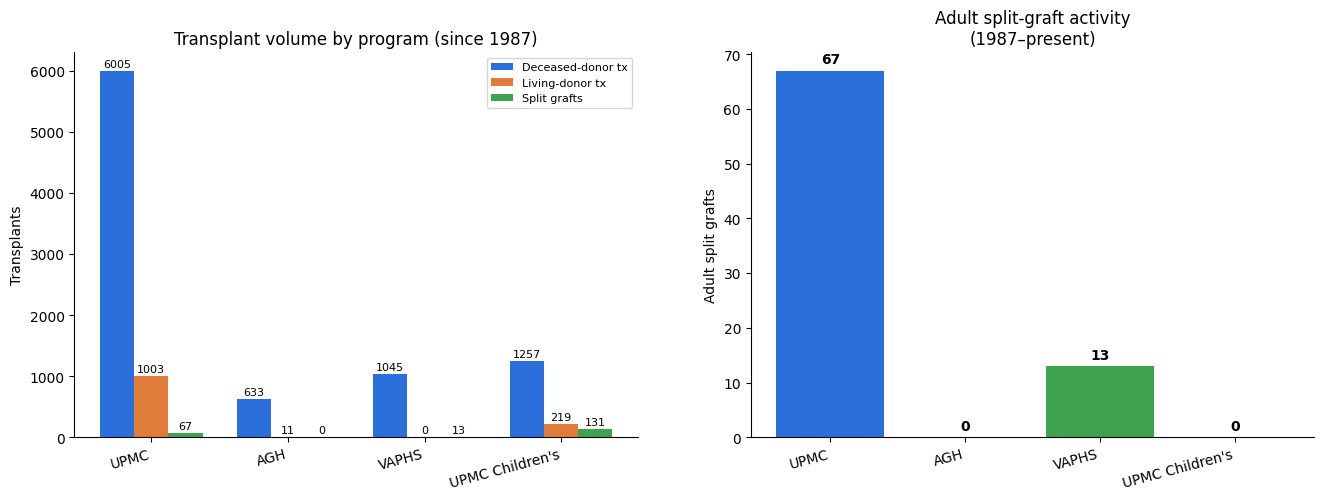

In [14]:
# VISUALIZE: Pittsburgh programs since START_YEAR 
df = pd.DataFrame(rows)

def to_num(x):
    """Parse safe()/pct() string output back to a float. Returns np.nan for suppressed/'<11'/missing."""
    if x is None or x == "" or x == "suppressed":
        return np.nan
    if isinstance(x, str) and x.startswith("<"):
        return np.nan
    if isinstance(x, str) and x.endswith("%"):
        return float(x.rstrip("%"))
    try:
        return float(x)
    except (TypeError, ValueError):
        return np.nan

df["deceased_n"]   = df["deceased-donor tx"].map(to_num)
df["living_n"]     = df["living-donor tx"].map(to_num)
df["split_n"]      = df["split grafts"].map(to_num)
df["adult_split_n"]= df["adult split grafts"].map(to_num)
df["star_surv"]    = df["STAR adult 1-yr survival"].map(to_num)
df["psr_alpha_pct"]= df["PSR alpha"].map(lambda v: v * 100 if isinstance(v, (int, float)) else np.nan)

programs = df["program"].tolist()
x = np.arange(len(programs))
colors = ["#2a6fdb", "#e07b39", "#3fa34d", "#9b59b6"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Panel 1: transplant volumes
width = 0.25
axes[0].bar(x - width, df["deceased_n"], width, label="Deceased-donor tx", color="#2a6fdb")
axes[0].bar(x,          df["living_n"],   width, label="Living-donor tx",   color="#e07b39")
axes[0].bar(x + width,  df["split_n"],    width, label="Split grafts",      color="#3fa34d")
for i, v in enumerate(df["deceased_n"]):
    if pd.notna(v): axes[0].text(x[i] - width, v + max(df["deceased_n"])*0.01, f"{v:.0f}", ha="center", fontsize=8)
for i, v in enumerate(df["living_n"]):
    if pd.notna(v): axes[0].text(x[i], v + max(df["deceased_n"])*0.01, f"{v:.0f}", ha="center", fontsize=8)
for i, v in enumerate(df["split_n"]):
    if pd.notna(v): axes[0].text(x[i] + width, v + max(df["deceased_n"])*0.01, f"{v:.0f}", ha="center", fontsize=8)
axes[0].set_xticks(x); axes[0].set_xticklabels(programs, rotation=15, ha="right")
axes[0].set_ylabel("Transplants")
axes[0].set_title(f"Transplant volume by program (since {START_YEAR})")
axes[0].legend(fontsize=8)
axes[0].spines[["top", "right"]].set_visible(False)

# Panel 2: adult split grafts (the real bandit-arm activity count)
axes[1].bar(programs, df["adult_split_n"], color=colors[:len(programs)])
for i, v in enumerate(df["adult_split_n"]):
    if pd.notna(v):
        axes[1].text(i, v + max(df["adult_split_n"].fillna(0))*0.02, f"{v:.0f}", ha="center", fontsize=10, fontweight="bold")
axes[1].set_xticks(range(len(programs))); axes[1].set_xticklabels(programs, rotation=15, ha="right")
axes[1].set_ylabel("Adult split grafts")
axes[1].set_title(f"Adult split-graft activity\n({START_YEAR}–present)")
axes[1].spines[["top", "right"]].set_visible(False)


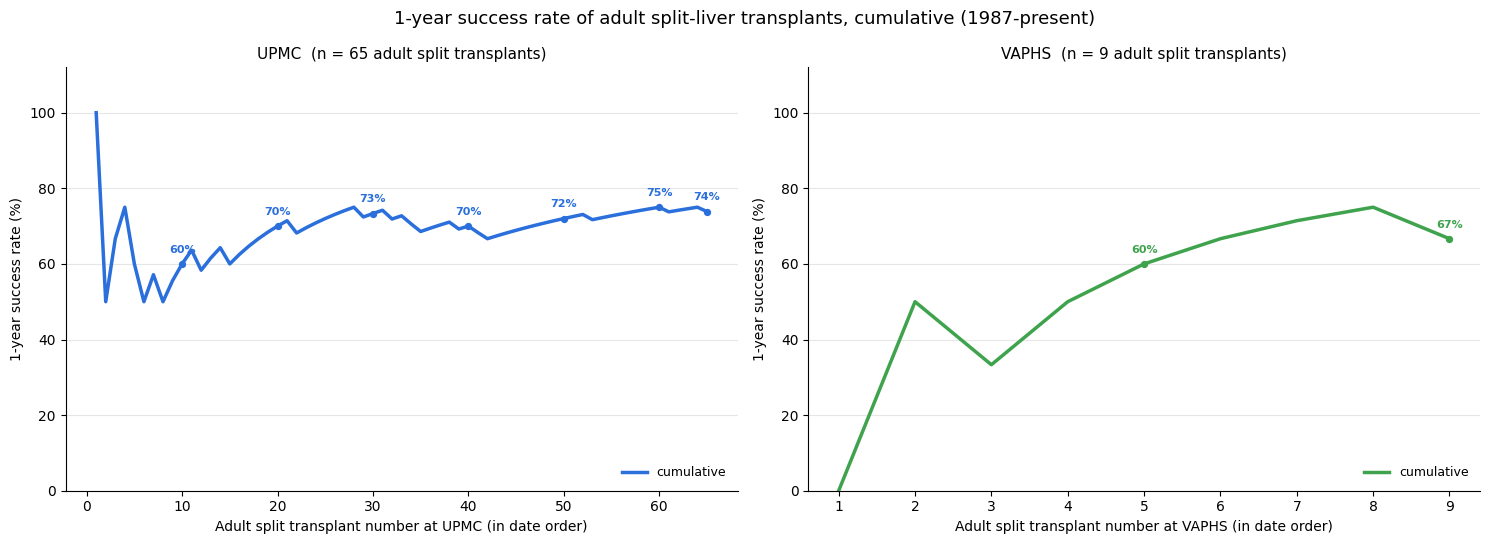

In [15]:
# PITTSBURGH CENTERS: cumulative 1-year success rate of adult split transplants

PGH = {"PAPT": "UPMC", "PAVA": "VAPHS"}
FROM_DATE = f"{START_YEAR}-01-01"
BLOCK = 5            # per-block dashed line uses this many transplants per point
colors = {"UPMC": "#2a6fdb", "VAPHS": "#3fa34d"}

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
for ax, (code, name) in zip(axes, PGH.items()):
    g = (liver[(liver["CODE"] == code) & liver["SPLIT"] & liver["ADULT"] & liver["KNOWN"]
               & (liver["TX_DATE"] >= FROM_DATE)]
         .sort_values("TX_DATE").reset_index(drop=True))

    ax.set_title(f"{name}  (n = {len(g)} adult split transplants)", fontsize=11)
    ax.set_xlabel(f"Adult split transplant number at {name} (in date order)")
    ax.set_ylabel("1-year success rate (%)")
    ax.tick_params(labelleft=True)                           # keep y tick numbers on the right-hand panel too
    ax.set_ylim(0, 112)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e6e6e6", lw=0.8)

    if g.empty:
        ax.text(0.5, 0.5, "No adult split transplants\nwith known 1-year outcome",
                ha="center", va="center", transform=ax.transAxes, color="gray")
        continue

    # Cumulative success rate after the k-th transplant
    k = np.arange(1, len(g) + 1)
    cum = g["SURV1"].cumsum().to_numpy() / k * 100

    ax.plot(k, cum, color=colors[name], lw=2.5, label="cumulative")

    # Label the cumulative line about 10 times per panel, plus the final value
    step = max(BLOCK, int(np.ceil(len(g) / 10 / BLOCK)) * BLOCK)
    label_at = sorted(set(list(range(step, len(g) + 1, step)) + [len(g)]))
    for kk in label_at:
        ax.scatter(kk, cum[kk - 1], color=colors[name], s=18, zorder=3)
        ax.annotate(f"{cum[kk - 1]:.0f}%", (kk, cum[kk - 1]), textcoords="offset points", xytext=(0, 8),
                    ha="center", fontsize=8, fontweight="bold", color=colors[name])
    ax.legend(loc="lower right", frameon=False, fontsize=9)

fig.suptitle(f"1-year success rate of adult split-liver transplants, cumulative ({START_YEAR}-present)", fontsize=13)
plt.tight_layout()
plt.savefig("pittsburgh_success_cumulative.png", dpi=150, bbox_inches="tight")
plt.show()

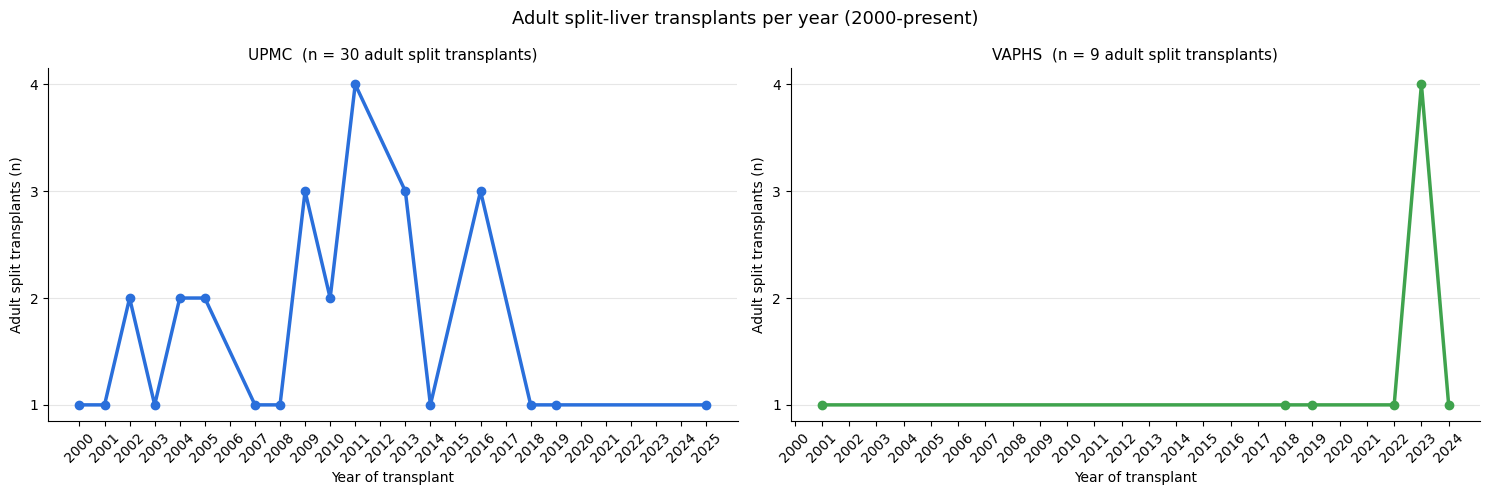

In [16]:
# Adult split transplants per year, 2000 onward
FROM_YEAR_PLOT = 2000

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)
for ax, (code, name) in zip(axes, PGH.items()):
    g = liver[(liver["CODE"] == code) & liver["SPLIT"] & liver["ADULT"] & liver["KNOWN"]
              & (liver["YEAR"] >= FROM_YEAR_PLOT)]

    n = g.groupby("YEAR").size()          # only years with at least one transplant

    ax.set_title(f"{name}  (n = {int(n.sum())} adult split transplants)", fontsize=11)
    ax.set_xlabel("Year of transplant")
    ax.set_ylabel("Adult split transplants (n)")
    ax.tick_params(labelleft=True)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#e6e6e6", lw=0.8)

    if n.empty:
        ax.text(0.5, 0.5, "No adult split transplants\nwith known 1-year outcome",
                ha="center", va="center", transform=ax.transAxes, color="gray")
        continue

    ax.plot(n.index, n.values, marker="o", color=colors[name], lw=2.5)
    ax.set_xticks(range(FROM_YEAR_PLOT, int(n.index.max()) + 1))
    ax.yaxis.get_major_locator().set_params(integer=True)
    ax.tick_params(axis="x", rotation=45)

fig.suptitle(f"Adult split-liver transplants per year ({FROM_YEAR_PLOT}-present)", fontsize=13)
plt.tight_layout()
plt.savefig("pittsburgh_split_n_by_year.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Is there a learning curve? → ω
L-UCB assumes survival rises with a center's split experience: θ(s) = α / (1 + e^-(s − ω)).
If survival is flat across experience, ω is very small and L-UCB behaves like plain UCB.
Experience = the number of split grafts the same center did before this one (counted since April 1987).

Sample: 2000+ | n = 4,119 grafts | 126 programs
Year-adjusted OR per doubling of experience: 0.97 [0.91, 1.03], p = 0.254
Verdict: no clear learning curve (CI includes 1)
              n  centers  surv_pct
EXP_BIN                           
1st-5th     356      100      84.8
6th-10th    327       78      84.1
11th-20th   570       65      85.1
21st-50th  1173       58      85.8
51st+      1693       29      87.8


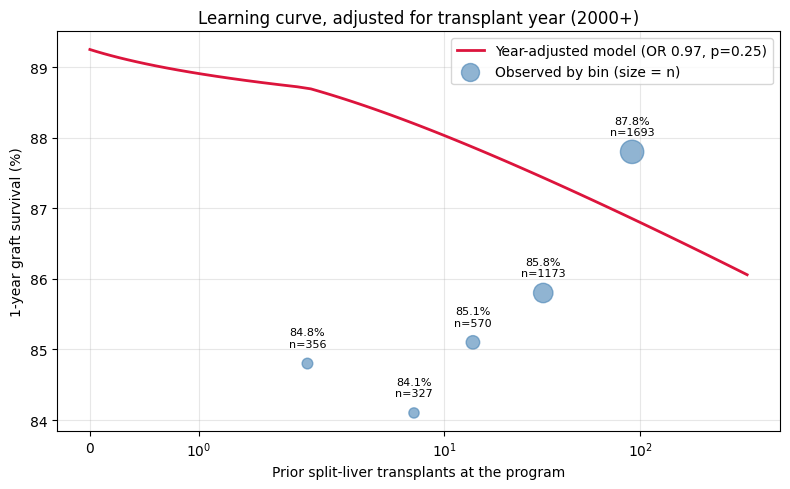

In [17]:
# Learning curve: year-adjusted model only
# --- 1. Prior split experience of each program, at the time of each graft
START_YEAR = 2000
sp = liver[liver["SPLIT"]].sort_values("TX_DATE").copy()
sp["PRIOR"] = (sp.groupby("TX_CTR")["TX_DATE"]
                 .rank(method="min").astype(int) - 1)

# --- 2. Fitting sample: known outcome, from START_YEAR onward
fit_data = sp[sp["KNOWN"] & (sp["YEAR"] >= START_YEAR)].copy()
fit_data["LOG_EXP"] = np.log2(1 + fit_data["PRIOR"])      # per doubling of experience
fit_data["PED"]     = (~fit_data["ADULT"]).astype(int)    # pediatric recipient
fit_data["YEAR_C"]  = fit_data["YEAR"] - fit_data["YEAR"].mean()

# --- 3. Year-adjusted logistic model, SEs clustered by program
groups = pd.factorize(fit_data["TX_CTR"])[0]
m = smf.glm("SURV1 ~ LOG_EXP + PED + YEAR_C", data=fit_data,
            family=sm.families.Binomial()).fit(
            cov_type="cluster", cov_kwds={"groups": groups})

# --- 4. Results
b, se, p = m.params["LOG_EXP"], m.bse["LOG_EXP"], m.pvalues["LOG_EXP"]
OR, lo, hi = np.exp(b), np.exp(b - 1.96*se), np.exp(b + 1.96*se)

print(f"Sample: {START_YEAR}+ | n = {len(fit_data):,} grafts | "
      f"{fit_data['TX_CTR'].nunique()} programs")
print(f"Year-adjusted OR per doubling of experience: "
      f"{OR:.2f} [{lo:.2f}, {hi:.2f}], p = {p:.3f}")

if lo > 1:
    verdict = "learning curve detected (survival improves with experience)"
elif hi < 1:
    verdict = "survival is WORSE with experience"
else:
    verdict = "no clear learning curve (CI includes 1)"
print("Verdict:", verdict)

# --- 5. Survival by experience bin (descriptive, same sample)
bins   = [-1, 4, 9, 19, 49, 10**6]
labels = ["1st-5th", "6th-10th", "11th-20th", "21st-50th", "51st+"]
fit_data["EXP_BIN"] = pd.cut(fit_data["PRIOR"], bins=bins, labels=labels)
tab = (fit_data.groupby("EXP_BIN", observed=True)
       .agg(n=("SURV1", "size"),
            centers=("TX_CTR", "nunique"),
            surv=("SURV1", "mean")))
tab["surv_pct"] = (tab["surv"] * 100).round(1)
print(tab[["n", "centers", "surv_pct"]])

# --- 6. Figure: adjusted model prediction vs observed bins
grid = pd.DataFrame({"LOG_EXP": np.linspace(0, fit_data["LOG_EXP"].max(), 100)})
grid["PED"] = 0
grid["YEAR_C"] = 0                      # at the average transplant year
grid["pred"] = m.predict(grid)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(2**grid["LOG_EXP"] - 1, grid["pred"]*100, color="crimson", lw=2,
        label=f"Year-adjusted model (OR {OR:.2f}, p={p:.2f})")
mid = fit_data.groupby("EXP_BIN", observed=True)["PRIOR"].median()
ax.scatter(mid, tab["surv_pct"], s=tab["n"]/6, alpha=.6, color="steelblue",
           label="Observed by bin (size = n)")
for x, y, n in zip(mid, tab["surv_pct"], tab["n"]):
    ax.annotate(f"{y:.1f}%\nn={n}", (x, y), textcoords="offset points",
                xytext=(0, 12), ha="center", fontsize=8)
ax.set_xscale("symlog")
ax.set_xlabel("Prior split-liver transplants at the program")
ax.set_ylabel("1-year graft survival (%)")
ax.set_title(f"Learning curve, adjusted for transplant year ({START_YEAR}+)")
ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

While the raw observed data (blue circles) visually suggest that survival rates improve as a hospital does more transplants, the statistical model (red line) indicates that center volume/experience alone is not a statistically significant driver of 1-year graft survival once you control for the era or year in which the transplant took place.

This is also why Tang et al. do not attempt to estimate ω (the learning-curve shift) from historical transplant outcomes. Instead, they elicit it directly from surgeon expert judgment, which is UCSF surgeons' estimate that a team becomes "sufficiently experienced" after roughly 6–15 split-liver surgeries. We adopt the same approach here (drawing ω ∈ [1, 14] per program, Section 6), treating ω as a documented modeling assumption informed by domain expertise rather than a value fit to STAR data.

## 5. Do the covariates predict split results? → the covariate prior
The model builds its prior from LDLT volume and having a pediatric program. If these signals are useful, centers with
more living-donor experience (or a pediatric program) should have better split-graft survival.

In [18]:
recent = liver[liver["YEAR"] >= START_YEAR].copy()
recent["LDLT"] = recent["DON_TY"] == "L"                    # living-donor liver transplant

# LDLT count for EVERY center in the data (centers with none get 0)
per_center = recent.groupby("TX_CTR")["LDLT"].sum().to_frame("ldlt")
per_center["LDLT_GROUP"] = pd.cut(per_center["ldlt"], [-1, 0, 49, 10**6],
                                  labels=["no LDLT", "1-49 LDLT", "50+ LDLT"])

splits = recent[recent["SPLIT"] & recent["KNOWN"]].merge(
    per_center, left_on="TX_CTR", right_index=True, how="left")

print(f"One-year split-graft survival by center LDLT volume (split grafts since {START_YEAR})")
for level, g in splits.groupby("LDLT_GROUP", observed=True):
    print(f"  {str(level):12s} {100 * g['SURV1'].mean():5.1f}%  "
          f"(grafts {safe(len(g))}, centers {safe(g['TX_CTR'].nunique())})")

One-year split-graft survival by center LDLT volume (split grafts since 2000)
  no LDLT       84.1%  (grafts 82, centers 22)
  1-49 LDLT     85.4%  (grafts 992, centers 53)
  50+ LDLT      86.7%  (grafts 3045, centers 51)


split-graft survival is about the same whether or not a center does living-donor liver transplants (LDLT), and however many it does. It's a flat pattern, so LDLT volume doesn't look like a useful marker of surgeon skill here.